# Module 3 - Data Project

In [1]:
#install packages
install.packages("tableone")
install.packages("Matching")
install.packages("ipw")
install.packages("survey")
install.packages("MatchIt")
library(tableone)
library(Matching)
library(ipw)
library(survey)
library(MatchIt)   # <<<< last to get the lalonde from MatchIt

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: MASS

## 
##  Matching (Version 4.10-15, Build Date: 2024-10-14)
##  See https://www.jsekhon.com for additional documentation.
##  Please cite software as:
##   Jasjeet S. Sekhon. 2011. ``Multivariate and Propensity Score Matching
##   Software with Automated Balance Optimization: The Matching package for R.''
##   Journal of Statistical Software, 42(7): 1-52. 
##


Loading required package: grid

Loading required package: Matrix

Loading required package: survival


Attaching package: ‘survey’


The following object is masked from ‘package:graphics’:

    dotcha

In [2]:
# two versions of lalonde data, get the right one
data(lalonde)
View(lalonde)

,treat,age,educ,race,married,nodegree,re74,re75,re78
,<int>,<int>,<int>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>
NSW1,1,37,11,black,1,1,0,0,9930.0460
NSW2,1,22,9,hispan,0,1,0,0,3595.8940
NSW3,1,30,12,black,0,0,0,0,24909.4500
NSW4,1,27,11,black,0,1,0,0,7506.1460
NSW5,1,33,8,black,0,1,0,0,289.7899
NSW6,1,22,9,black,0,1,0,0,4056.4940
NSW7,1,23,12,black,0,0,0,0,0.0000
NSW8,1,32,11,black,0,1,0,0,8472.1580
NSW9,1,22,16,black,0,0,0,0,2164.0220


In [3]:
xvars<-c("age","educ","race","married","nodegree","re74",
         "re75")
matchedtab1<-CreateTableOne(vars=xvars, strata ="treat", 
                            data=lalonde, test = FALSE)
print(matchedtab1, smd = TRUE)

                      Stratified by treat
                       0                 1                 SMD   
  n                        429               185                 
  age (mean (SD))        28.03 (10.79)     25.82 (7.16)     0.242
  educ (mean (SD))       10.24 (2.86)      10.35 (2.01)     0.045
  race (%)                                                  1.701
     black                  87 (20.3)        156 (84.3)          
     hispan                 61 (14.2)         11 ( 5.9)          
     white                 281 (65.5)         18 ( 9.7)          
  married (mean (SD))     0.51 (0.50)       0.19 (0.39)     0.719
  nodegree (mean (SD))    0.60 (0.49)       0.71 (0.46)     0.235
  re74 (mean (SD))     5619.24 (6788.75) 2095.57 (4886.62)  0.596
  re75 (mean (SD))     2466.48 (3292.00) 1532.06 (3219.25)  0.287


In [17]:
#propensity score model
psmodel <- glm(treat ~ age+educ+race+married+nodegree+re74+re75,
               family = binomial(link ="logit"), data = lalonde)

## value of propensity score for each subject
ps <-predict(psmodel, type = "response")

#create weights
weight<-ifelse(lalonde$treat==1,1/(ps),1/(1-ps))

print(max(weight))
print(min(weight))
print(summary(weight))

[1] 40.07729
[1] 1.009163
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.009   1.052   1.170   1.905   1.623  40.077 


In [18]:
#apply weights to data
weighteddata<-svydesign(ids = ~ 1, data =lalonde, weights = ~ weight)

#weighted table 1
weightedtable <-svyCreateTableOne(vars = xvars, strata = "treat", 
                                 data = weighteddata, test = FALSE)
## Show table with SMD
print(weightedtable, smd = TRUE)

                      Stratified by treat
                       0                 1                 SMD   
  n                     616.00            553.63                 
  age (mean (SD))        27.10 (10.80)     25.57 (6.53)     0.172
  educ (mean (SD))       10.29 (2.74)      10.61 (2.05)     0.132
  race (%)                                                  0.112
     black               245.1 (39.8)      247.9 (44.8)          
     hispan               72.1 (11.7)       67.4 (12.2)          
     white               298.8 (48.5)      238.3 (43.0)          
  married (mean (SD))     0.41 (0.49)       0.31 (0.47)     0.197
  nodegree (mean (SD))    0.62 (0.48)       0.57 (0.50)     0.112
  re74 (mean (SD))     4552.74 (6337.09) 2932.18 (5709.42)  0.269
  re75 (mean (SD))     2172.04 (3160.14) 1658.07 (3072.89)  0.165


In [24]:
mydata=data.frame(lalonde)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.009   1.052   1.170   1.905   1.623  40.077 

(Intercept)       treat 
  6422.8390    224.6763

,2.5 %,97.5 %
(Intercept),5705.529,7140.149
treat,-1562.856,2012.208


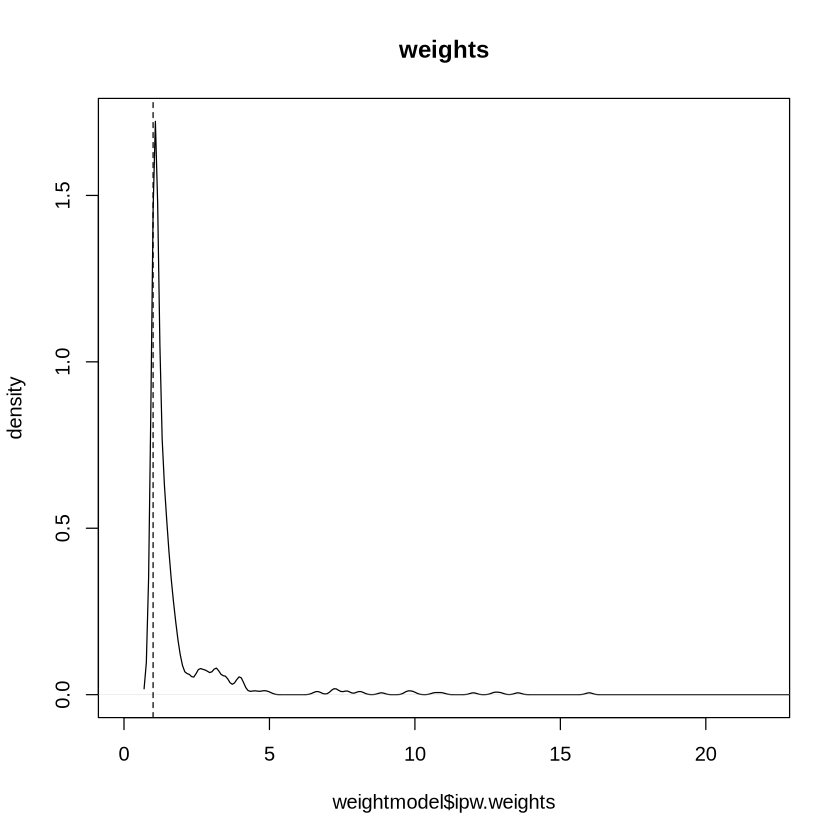

In [25]:
#first fit propensity score model to get weights
weightmodel<-ipwpoint(exposure= treat, family = "binomial", link ="logit",
          denominator= ~ age+educ+race+married+nodegree+re74+re75, data=lalonde)
#numeric summary of weights
summary(weightmodel$ipw.weights)

#plot of weights
ipwplot(weights = weightmodel$ipw.weights, logscale = FALSE,
         main = "weights", xlim = c(0, 22))
mydata$wt<-weightmodel$ipw.weights

#fit a marginal structural model (risk difference)
msm <- (svyglm(re78 ~ treat, design = svydesign(~ 1, weights = ~wt,
                  data =mydata)))
coef(msm)
confint(msm)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.012   1.052   1.170   1.818   1.623  12.631 

(Intercept)       treat 
  6422.9362    486.9336

,2.5 %,97.5 %
(Intercept),5705.614,7140.258
treat,-1093.765,2067.632


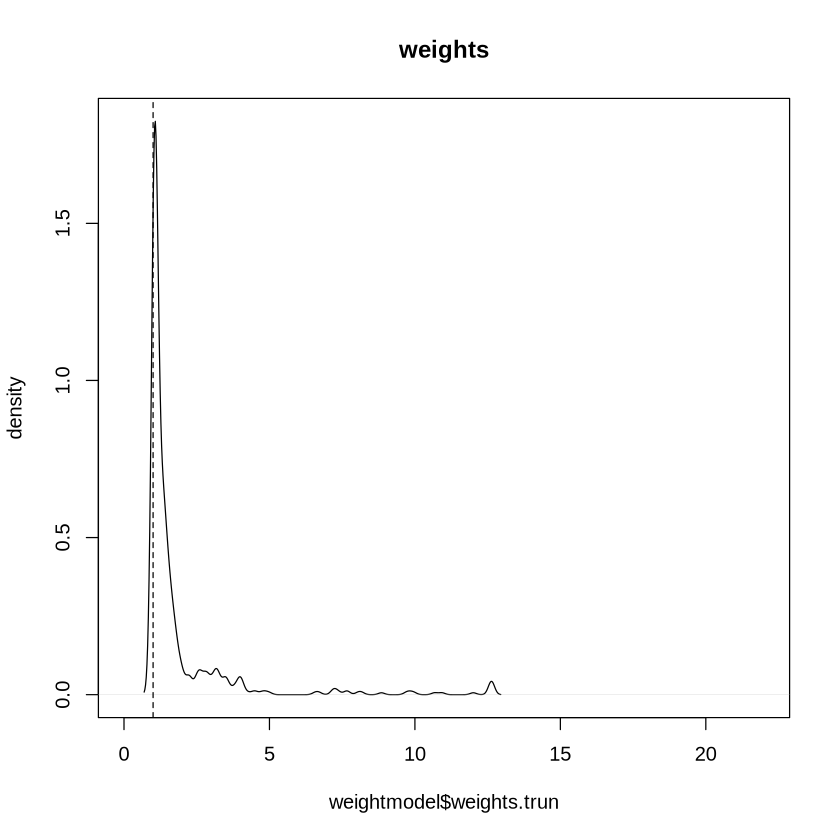

In [27]:
# fit propensity score model to get weights, but truncated
weightmodel<-ipwpoint(exposure= treat, family = "binomial", link ="logit",
                      denominator= ~ age+educ+race+married+nodegree+re74+re75,
                      data=mydata,trunc=.01)

#numeric summary of weights
summary(weightmodel$weights.trun)
#plot of weights
ipwplot(weights = weightmodel$weights.trun, logscale = FALSE,
        main = "weights", xlim = c(0, 22))
mydata$wt<-weightmodel$weights.trun
#fit a marginal structural model (risk difference)
msm <- (svyglm(re78 ~ treat, design = svydesign(~ 1, weights = ~wt,
                                                    data =mydata)))
coef(msm)
confint(msm)